<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad estudiar el efecto de distintas ventanas sobre la estimación espectral de una señal senoidal. Para ello, se generan múltiples realizaciones de una señal de frecuencia ligeramente variable alrededor de una frecuencia central, a la cual se le agrega ruido blanco gaussiano con distintos niveles de SNR. Luego, se calcula la FFT para analizar cómo cambia la estimación de amplitud y frecuencia según la ventana utilizada.

Para ello generaremos la siguiente senoidal: x(k)=a0⋅sen(Ω1⋅n)+na(n)

donde: 

-a0 = 2

-Ω1 = Ω0 + fr⋅2$\pi$/N

-Ω0 = $\pi$/2

-fr ∼ U(−2,2)

-na ∼ N(0,$σ^{2}$)

-fs = 1000hz

Para esto construiremos una matriz de 200 realizaciones R de la señal senoidal que posee 1000 muestras N. Y la agregaremos diferentes ventanas a la senoidal.


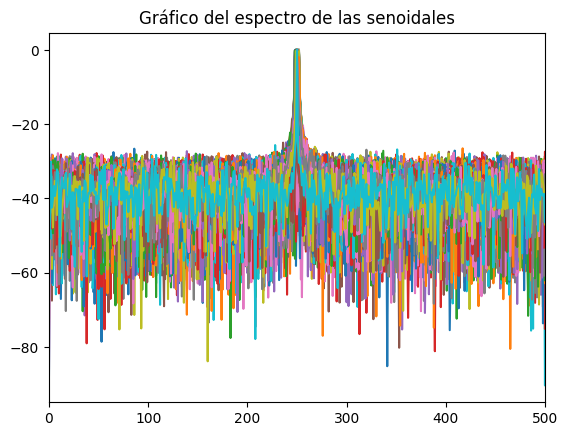

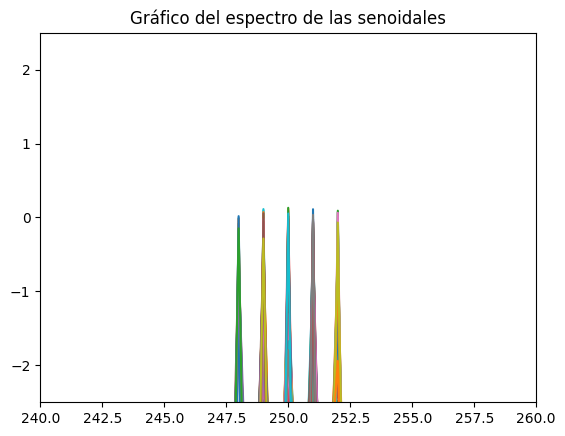

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

a0 = np.sqrt(2)
N = 1000
R = 200
fs = 1000

fr = np.random.uniform(-2, 2, R)

w1 = np.ones(N)
w2 = signal.windows.flattop(N)
w3 = signal.windows.blackmanharris(N)
w4 = signal.windows.chebwin(N, 50)

#matriz de las ventanas
w_mat1 = np.tile(w1.reshape(1, N), (R, 1))
w_mat2 = np.tile(w2.reshape(1, N), (R, 1))
w_mat3 = np.tile(w3.reshape(1, N), (R, 1))
w_mat4 = np.tile(w4.reshape(1, N), (R, 1))

om0 = N/4
om1 = om0 + fr * (N/N)

nn = np.arange(0 , N) *(1/fs)   

#Hago los reshapes para crear la matriz
om1_mat = np.tile(om1.reshape(R, 1), (1, N))

n_mat = np.tile(nn.reshape(1, N), (R, 1))

xx = a0 * np.sin(2 * np.pi * om1_mat * n_mat)


SNR = 10
#SNR = 3
pr = 10 ** (-SNR/10)
ruido = np.random.normal(0 , np.sqrt(pr) , (R, N))

sr = xx + ruido

#Calculo las fft multiplicandolas por la ventana correspondiente
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat1)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-2.5, 2.5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

En este caso usamos la ventana rectangular, podemos observar que el máximo de energía está en 250 en 0dB y hay 5 picos en total entre 248 y 252.

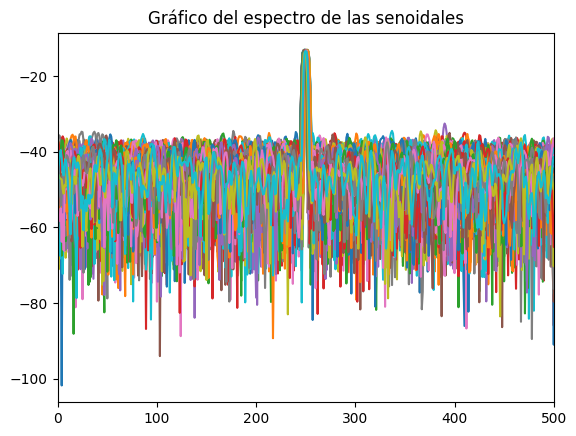

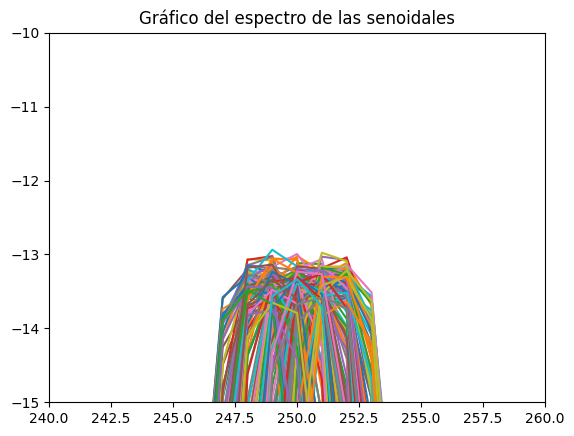

In [96]:
#Calculo las fft multiplicandolas por la ventana correspondiente
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat2)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-15, -10)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

En este caso usamos flattop, se puede observar que el máximo ya no está en 0, sino que cerca de -13dB y no se aprecian bien los 5 picos.

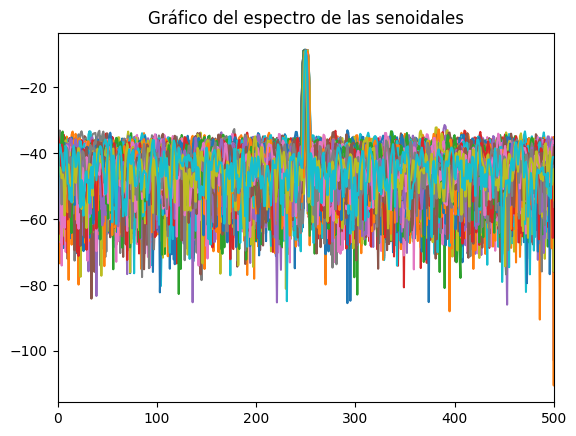

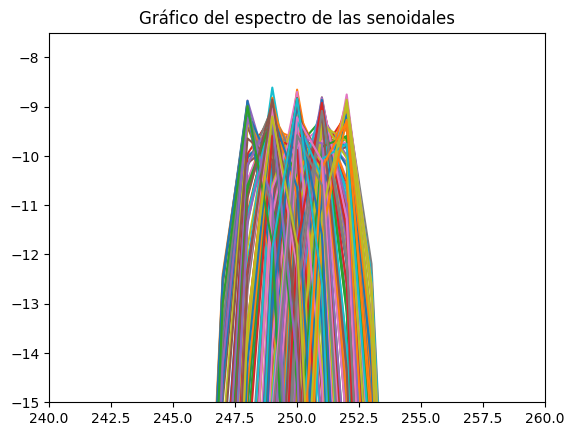

In [97]:
#Calculo las fft multiplicandolas por la ventana correspondiente
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat3)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-15, -7.5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

En este caso usamos blackmanharris, se puede apreciar que el máximo de energía se encuentra cerca de los -9dB. En este caso si se aprecian correctamente los 5 picos.

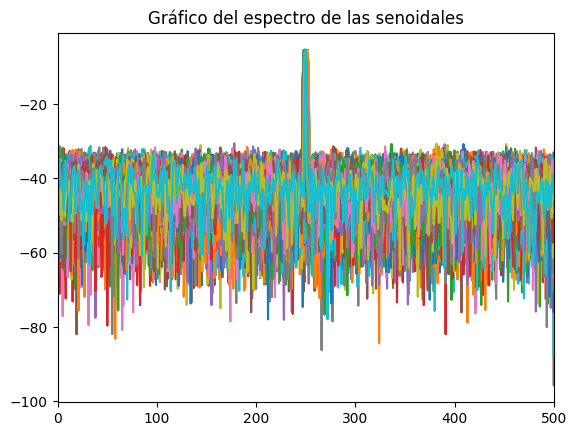

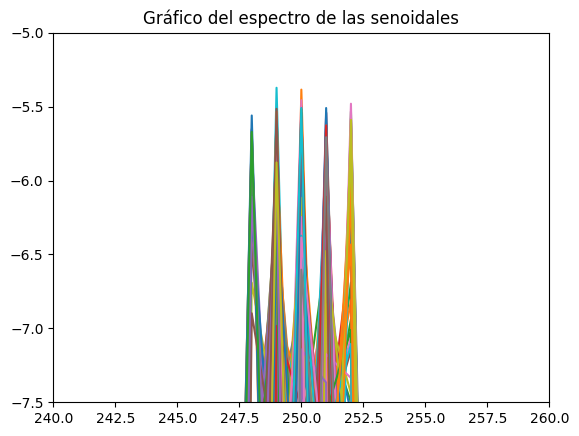

In [98]:
#Calculo las fft multiplicandolas por la ventana correspondiente
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat4)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-7.5, -5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

En este caso usamos una ventana de Dolph con una atenuación de 50 dB. Podemos observar 5 picos con un máximo cercano a -5.5 dB.

Ahora el buscaremos encontrar el sesgo y la varianza de cada estimador para cada ventana realizada. Para eso calcularemos la amplitud y la frecuencia para cada una de estas ventanas.

$a^{i}$1=|$X^{i}$w(Ω0)|=|F{x(n)⋅wi(n)}|

$Ω^{i}$1=arg max{|$X^{i}$w(Ω)|}

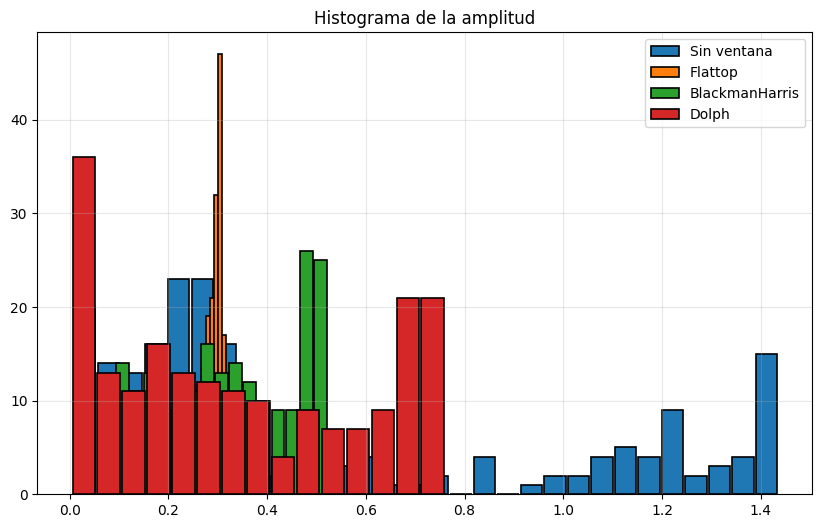

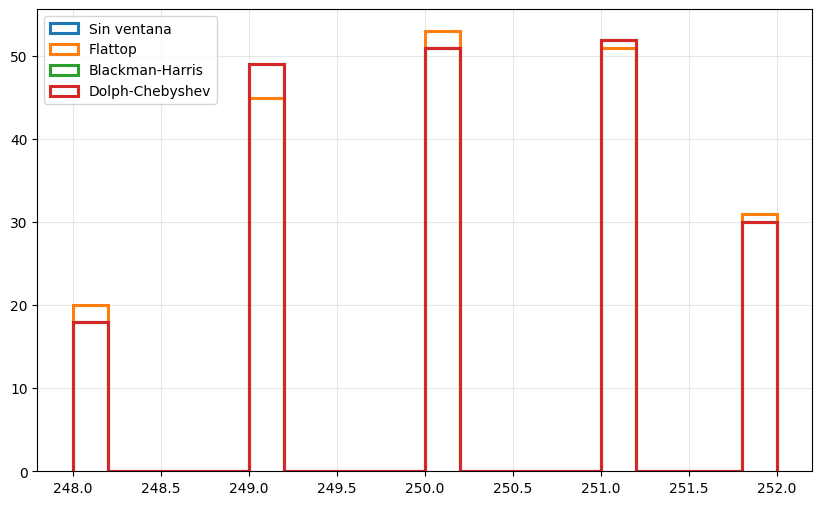


ESTIMACIÓN DE AMPLITUD
---------------------------------------------
Ventana                 s_a          v_a
---------------------------------------------
Rectangular              -0.914        0.223
Flat-top                  -1.14      0.00106
Blackman-Harris           -1.09       0.0176
Dolph-Chebyshev           -1.07       0.0663
---------------------------------------------

ESTIMACIÓN DE FRECUENCIA
---------------------------------------------
Ventana                 s_f          v_f
---------------------------------------------
Rectangular             -0.0111         1.45
Flat-top               -0.00612         1.48
Blackman-Harris         -0.0111         1.45
Dolph-Chebyshev         -0.0111         1.45
---------------------------------------------


In [99]:
#busco amplitud a1 y omega 1 para sin ventana
fft1 = np.fft.fft(sr * w_mat1)/N

#Normalizar por ganancia de la ventana
W_gain1 = np.sum(w1) / N

a1_s1  = 2 * np.abs(fft1[: , int(om0)]) 

magnitudes1 = 2 * np.abs(fft1[:, :N//2]) / W_gain1

sigma_s1 =  np.argmax(magnitudes1, axis = 1) 

sesgo_a1 = np.mean(a1_s1 - a0)

varianza_a1 = np.var(a1_s1)

sesgo_s1 = np.mean(sigma_s1 - om1) 

varianza_s1 = np.var(sigma_s1)


#busco amplitud a1 y omega 1 para ventana flattop
fft2 = np.fft.fft(sr * w_mat2)/N

#Normalizar por ganancia de la ventana
W_gain2 = np.sum(w2) / N

a1_s2  = 2 * np.abs(fft2[: , int(om0)]) 

magnitudes2 = 2 * np.abs(fft2[:, :N//2]) / W_gain2

sigma_s2 =  np.argmax(magnitudes2, axis = 1) 

sesgo_a2 = np.mean(a1_s2 - a0)

varianza_a2 = np.var(a1_s2)

sesgo_s2 = np.mean(sigma_s2 - om1) 

varianza_s2 = np.var(sigma_s2)


#busco amplitud a1 y omega 1 para ventana blackmanharris
fft3 = np.fft.fft(sr * w_mat3)/N

#Normalizar por ganancia de la ventana
W_gain3 = np.sum(w3) / N

a1_s3  = 2 * np.abs(fft3[: , int(om0)]) 

magnitudes3 = 2 * np.abs(fft3[:, :N//2]) / W_gain3

sigma_s3 =  np.argmax(magnitudes3, axis = 1) 

sesgo_a3 = np.mean(a1_s3 - a0)

varianza_a3 = np.var(a1_s3)

sesgo_s3 = np.mean(sigma_s3 - om1) 

varianza_s3 = np.var(sigma_s3)


#busco amplitud a1 y omega 1 para ventana dolph
fft4 = np.fft.fft(sr * w_mat4)/N

#Normalizar por ganancia de la ventana
W_gain4 = np.sum(w4) / N

a1_s4  = 2 * np.abs(fft4[: , int(om0)]) 

magnitudes4 = 2 * np.abs(fft4[:, :N//2]) / W_gain4

sigma_s4 =  np.argmax(magnitudes4, axis = 1) 

sesgo_a4 = np.mean(a1_s4 - a0)

varianza_a4 = np.var(a1_s4)

sesgo_s4 = np.mean(sigma_s4 - om1) 

varianza_s4 = np.var(sigma_s4)

plt.figure(figsize=(10, 6))
plt.hist(a1_s1, bins = 30, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Sin ventana')
plt.hist(a1_s2, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Flattop')
plt.hist(a1_s3, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'BlackmanHarris')
plt.hist(a1_s4, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Dolph')
plt.legend()
plt.grid(alpha=0.3)
plt.title("Histograma de la amplitud")
plt.show()

bins = 20
plt.figure(figsize=(10, 6))

plt.hist(sigma_s1, bins=bins, histtype="step", linewidth=2.2, color="tab:blue", label="Sin ventana")
plt.hist(sigma_s2, bins=bins, histtype="step", linewidth=2.2, color="tab:orange", label="Flattop")
plt.hist(sigma_s3, bins=bins, histtype="step", linewidth=2.2, color="tab:green", label="Blackman-Harris")
plt.hist(sigma_s4, bins=bins, histtype="step", linewidth=2.2, color="tab:red", label="Dolph-Chebyshev")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


print("\nESTIMACIÓN DE AMPLITUD")
print("-" * 45)
print(f"{'Ventana':<14} {'s_a':>12} {'v_a':>12}")
print("-" * 45)
print(f"{'Rectangular':<18} {sesgo_a1:>12.3} {varianza_a1:>12.3}")
print(f"{'Flat-top':<18} {sesgo_a2:>12.3} {varianza_a2:>12.3}")
print(f"{'Blackman-Harris':<18} {sesgo_a3:>12.3} {varianza_a3:>12.3}")
print(f"{'Dolph-Chebyshev':<18} {sesgo_a4:>12.3} {varianza_a4:>12.3}")
print("-" * 45)


print("\nESTIMACIÓN DE FRECUENCIA")
print("-" * 45)
print(f"{'Ventana':<14} {'s_f':>12} {'v_f':>12}")
print("-" * 45)
print(f"{'Rectangular':<18} {sesgo_s1:>12.3} {varianza_s1:>12.3}")
print(f"{'Flat-top':<18} {sesgo_s2:>12.3} {varianza_s2:>12.3}")
print(f"{'Blackman-Harris':<18} {sesgo_s3:>12.3} {varianza_s3:>12.3}")
print(f"{'Dolph-Chebyshev':<18} {sesgo_s4:>12.3} {varianza_s4:>12.3}")
print("-" * 45)

Análisis de amplitud:

En el caso rectangular, la estimación de amplitud presenta mayor dispersión debido al efecto de leakage. Como la frecuencia de la señal no coincide necesariamente con un bin exacto de la DFT, parte de la energía se distribuye hacia bins vecinos.

La ventana Flattop muestra un mejor comportamiento en la estimación de amplitud, ya que su diseño reduce el error producido cuando la frecuencia de la senoidal cae entre bins. Por este motivo, el histograma tiende a concentrarse alrededor del valor real a0, presentando un sesgo menor que otras ventanas.

La ventana Blackman-Harris presenta una dispersión moderada, menos leakage que rectangular y estimaciones más estables.

En la estimación de amplitud, la ventana Dolph-Chebyshev presenta un comportamiento intermedio: reduce el leakage respecto de la ventana rectangular, pero no está específicamente optimizada para estimar amplitudes como la ventana Flattop. Por este motivo, puede presentar un sesgo mayor que Flattop, aunque generalmente menor sensibilidad a los lóbulos laterales que la rectangular. Esto varía según la atenuación elegida.

Análisis de frecuencia: (Hay varios resultados superpuestos)

En este caso no se pudo encontrar una gran diferencia entre las ventanas. Esto sugiere que, bajo las condiciones simuladas, el máximo espectral pudo identificarse correctamente para la mayoría de las realizaciones. Las diferencias entre ventanas resultaron más relevantes en la estimación de amplitud que en la de frecuencia.

Ahora para SNR = 3dB:

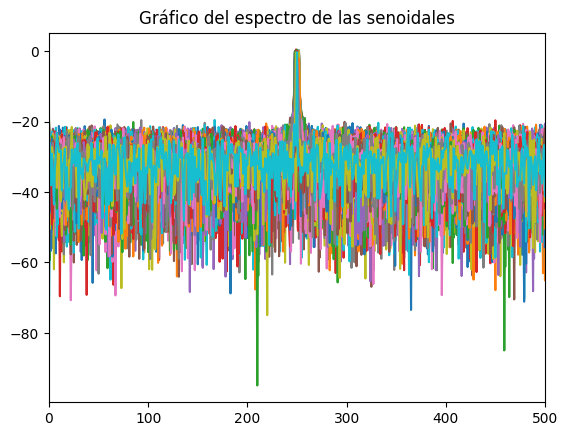

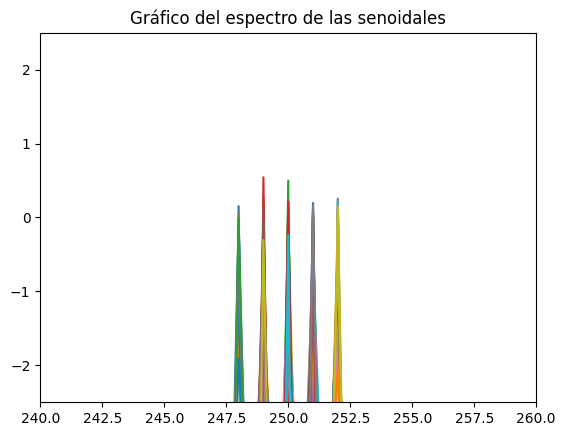

In [100]:
SNR = 3
pr = 10 ** (-SNR/10)
ruido = np.random.normal(0 , np.sqrt(pr) , (R, N))

sr = xx + ruido

#Calculo las fft multiplicandolas por la ventana correspondiente
#Rectangular
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat1)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-2.5, 2.5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

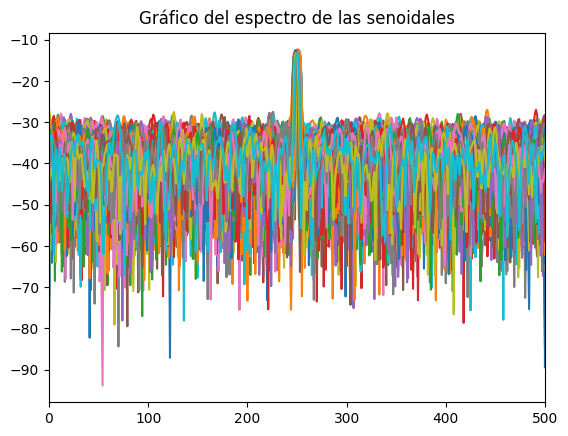

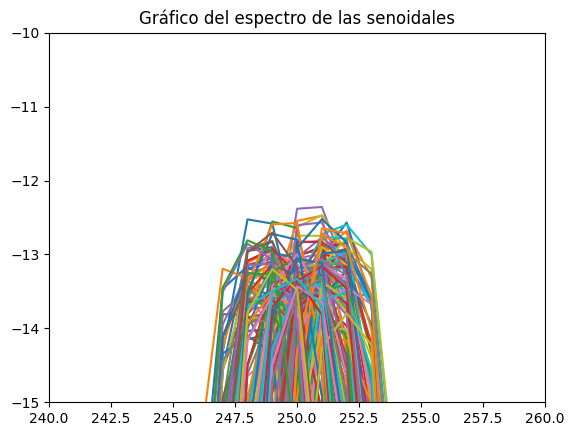

In [101]:
#Flattop
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat2)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-15, -10)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

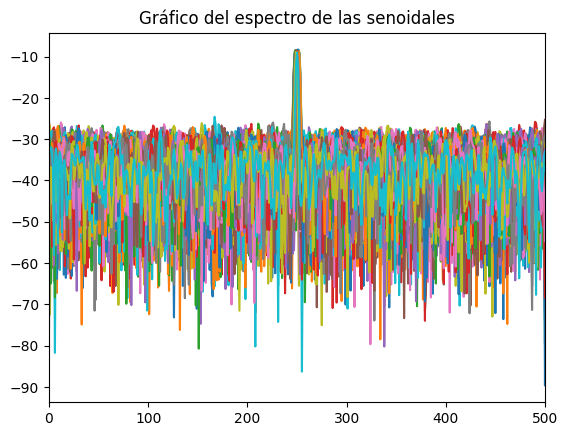

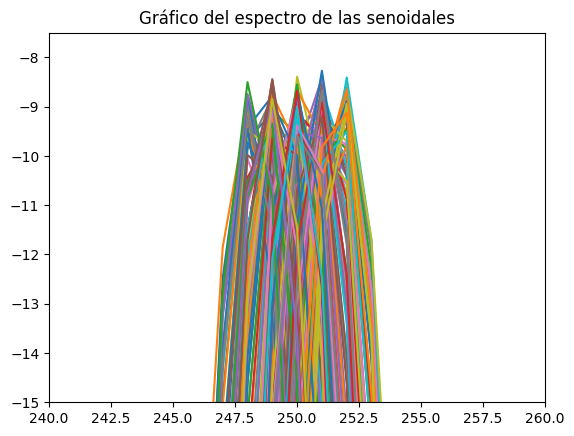

In [102]:
#BlackmanHarris
Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat3)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-15, -7.5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

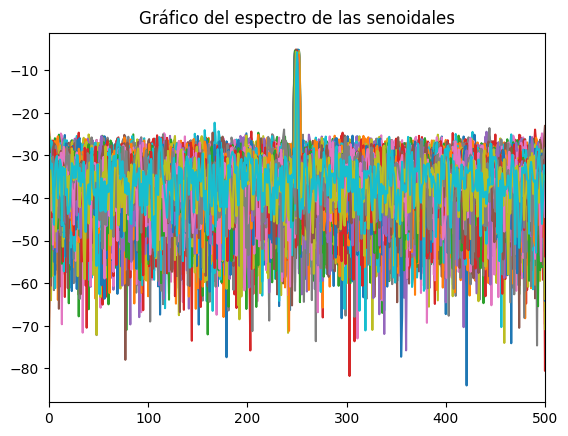

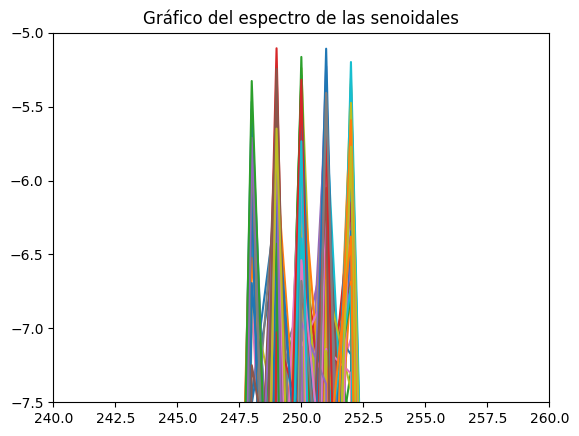

In [103]:
#Dolph

Srfft = 2 * (np.abs(np.fft.fft(sr * w_mat4)/N)**2)

Srfft_db = 10 * np.log10(Srfft[:N//2] + 1e-12)

plt.figure()
plt.xlim(0,fs/2)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

plt.figure()
plt.xlim(240,260)
plt.ylim(-7.5, -5)
plt.plot(Srfft_db.T)
plt.title('Gráfico del espectro de las senoidales' )
plt.show()

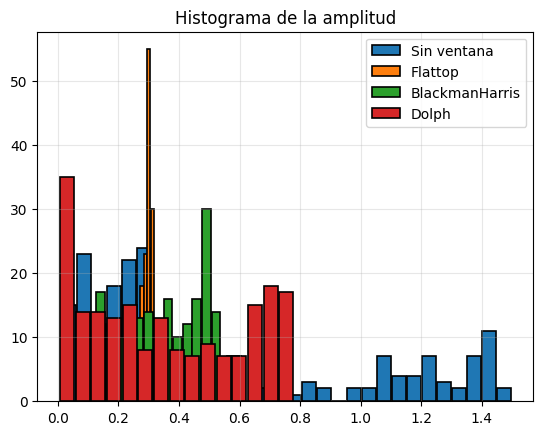

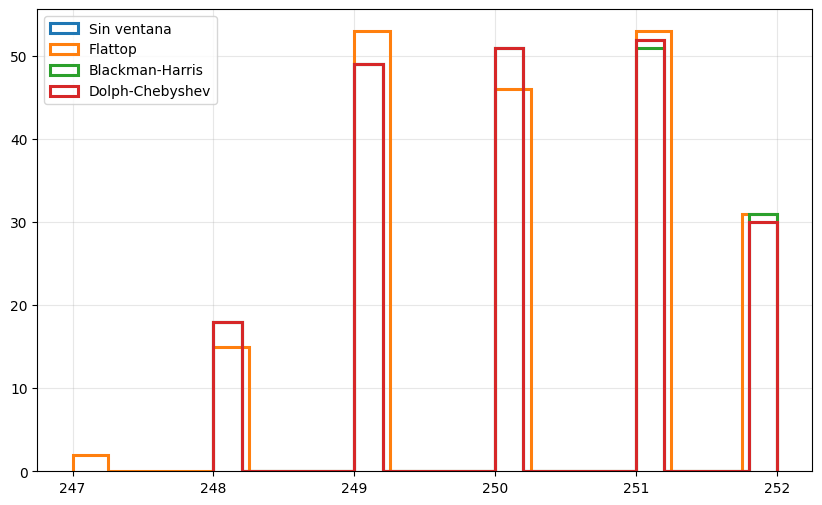


ESTIMACIÓN DE AMPLITUD
---------------------------------------------
Ventana                 s_a          v_a
---------------------------------------------
Rectangular              -0.907        0.224
Flat-top                  -1.13      0.00127
Blackman-Harris           -1.08       0.0181
Dolph-Chebyshev           -1.06       0.0657
---------------------------------------------

ESTIMACIÓN DE FRECUENCIA
---------------------------------------------
Ventana                 s_f          v_f
---------------------------------------------
Rectangular             -0.0111         1.45
Flat-top                -0.0161         1.52
Blackman-Harris        -0.00612         1.46
Dolph-Chebyshev         -0.0111         1.45
---------------------------------------------


In [104]:
#busco amplitud a1 y omega 1 para sin ventana
fft1 = np.fft.fft(sr * w_mat1)/N

#Normalizar por ganancia de la ventana
W_gain1 = np.sum(w1) / N

a1_s1  = 2 * np.abs(fft1[: , int(om0)]) 

magnitudes1 = 2 * np.abs(fft1[:, :N//2]) / W_gain1

sigma_s1 =  np.argmax(magnitudes1, axis = 1) 

sesgo_a1 = np.mean(a1_s1 - a0)

varianza_a1 = np.var(a1_s1)

sesgo_s1 = np.mean(sigma_s1 - om1) 

varianza_s1 = np.var(sigma_s1)


#busco amplitud a1 y omega 1 para ventana flattop
fft2 = np.fft.fft(sr * w_mat2)/N

#Normalizar por ganancia de la ventana
W_gain2 = np.sum(w2) / N

a1_s2  = 2 * np.abs(fft2[: , int(om0)]) 

magnitudes2 = 2 * np.abs(fft2[:, :N//2]) / W_gain2

sigma_s2 =  np.argmax(magnitudes2, axis = 1) 

sesgo_a2 = np.mean(a1_s2 - a0)

varianza_a2 = np.var(a1_s2)

sesgo_s2 = np.mean(sigma_s2 - om1) 

varianza_s2 = np.var(sigma_s2)


#busco amplitud a1 y omega 1 para ventana blackmanharris
fft3 = np.fft.fft(sr * w_mat3)/N

#Normalizar por ganancia de la ventana
W_gain3 = np.sum(w3) / N

a1_s3  = 2 * np.abs(fft3[: , int(om0)]) 

magnitudes3 = 2 * np.abs(fft3[:, :N//2]) / W_gain3

sigma_s3 =  np.argmax(magnitudes3, axis = 1) 

sesgo_a3 = np.mean(a1_s3 - a0)

varianza_a3 = np.var(a1_s3)

sesgo_s3 = np.mean(sigma_s3 - om1) 

varianza_s3 = np.var(sigma_s3)


#busco amplitud a1 y omega 1 para ventana dolph
fft4 = np.fft.fft(sr * w_mat4)/N

#Normalizar por ganancia de la ventana
W_gain4 = np.sum(w4) / N

a1_s4  = 2 * np.abs(fft4[: , int(om0)]) 

magnitudes4 = 2 * np.abs(fft4[:, :N//2]) / W_gain4

sigma_s4 =  np.argmax(magnitudes4, axis = 1) 

sesgo_a4 = np.mean(a1_s4 - a0)

varianza_a4 = np.var(a1_s4)

sesgo_s4 = np.mean(sigma_s4 - om1) 

varianza_s4 = np.var(sigma_s4)



plt.figure()
plt.hist(a1_s1, bins = 30, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Sin ventana')
plt.hist(a1_s2, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Flattop')
plt.hist(a1_s3, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'BlackmanHarris')
plt.hist(a1_s4, bins = 15, edgecolor="black", linewidth=1.2, rwidth=0.9, label = 'Dolph')
plt.legend()
plt.grid(alpha=0.3)
plt.title("Histograma de la amplitud")
plt.show()

bins = 20
plt.figure(figsize=(10, 6))

plt.hist(sigma_s1, bins=bins, histtype="step", linewidth=2.2, color="tab:blue", label="Sin ventana")
plt.hist(sigma_s2, bins=bins, histtype="step", linewidth=2.2, color="tab:orange", label="Flattop")
plt.hist(sigma_s3, bins=bins, histtype="step", linewidth=2.2, color="tab:green", label="Blackman-Harris")
plt.hist(sigma_s4, bins=bins, histtype="step", linewidth=2.2, color="tab:red", label="Dolph-Chebyshev")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


print("\nESTIMACIÓN DE AMPLITUD")
print("-" * 45)
print(f"{'Ventana':<14} {'s_a':>12} {'v_a':>12}")
print("-" * 45)
print(f"{'Rectangular':<18} {sesgo_a1:>12.3} {varianza_a1:>12.3}")
print(f"{'Flat-top':<18} {sesgo_a2:>12.3} {varianza_a2:>12.3}")
print(f"{'Blackman-Harris':<18} {sesgo_a3:>12.3} {varianza_a3:>12.3}")
print(f"{'Dolph-Chebyshev':<18} {sesgo_a4:>12.3} {varianza_a4:>12.3}")
print("-" * 45)


print("\nESTIMACIÓN DE FRECUENCIA")
print("-" * 45)
print(f"{'Ventana':<14} {'s_f':>12} {'v_f':>12}")
print("-" * 45)
print(f"{'Rectangular':<18} {sesgo_s1:>12.3} {varianza_s1:>12.3}")
print(f"{'Flat-top':<18} {sesgo_s2:>12.3} {varianza_s2:>12.3}")
print(f"{'Blackman-Harris':<18} {sesgo_s3:>12.3} {varianza_s3:>12.3}")
print(f"{'Dolph-Chebyshev':<18} {sesgo_s4:>12.3} {varianza_s4:>12.3}")
print("-" * 45)

Al bajar el SNR se aprecia mas ruido. Esto se observa en el espectro como un aumento del piso de ruido, haciendo que el pico correspondiente a la senoidal sea menos distinguible. Como consecuencia, los estimadores de amplitud y frecuencia presentan mayor dispersión.

En este trabajo aprendimos como distintas ventanas afectan directamente sobre la estimación de amplitud y frecuencia. Para la estimación de la amplitud la ventana de flattop es la mas conveniente ya que está diseñada para reducir el error cuando la frecuencia no coincide exactamente con un bin de la DFT. En cambio, para la estimación de frecuencia, las diferencias entre ventanas fueron menos marcadas.
Al disminuir el SNR, el ruido tuvo mayor influencia sobre los resultados, aumentando principalmente la dispersión de las estimaciones. Esto se reflejó en histogramas más anchos y en un aumento de la varianza.